# 기초 파이썬 과제 — 삼성전자 주가 시계열 예측
**학번:** S69031 &nbsp;&nbsp; **이름:** 황석준

## 1. 데이터 수집

In [1]:
# !pip install finance-datareader
import FinanceDataReader as fdr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### 1.1 KOSPI 전체 종목 코드

In [2]:
kospi_cd = fdr.StockListing('KOSPI')
kospi_cd.head()

,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId
0,005930,KR7005930003,삼성전자,KOSPI,NaN,344000,1,27000,8.52,319500,350000,319500,33149670,11200070405750,2011119841152000,5846278608,STK
1,000660,KR7000660001,SK하이닉스,KOSPI,NaN,2346000,1,13000,0.56,2299000,2398000,2296000,4276817,10049178356000,1671999748290000,712702365,STK
2,005935,KR7005931001,삼성전자우,KOSPI,NaN,227500,1,25000,12.35,203500,235000,203000,10983971,2445136883652,182539448682500,802371203,STK
3,402340,KR7402340004,SK스퀘어,KOSPI,NaN,1242000,1,9000,0.73,1249000,1289000,1210000,863712,1078489509000,163892315412000,131958386,STK
4,005380,KR7005380001,현대차,KOSPI,NaN,747000,1,24000,3.32,736000,783000,727000,2424200,1832625469500,152954051202000,204757766,STK


### 1.2 삼성전자 종목 코드 확인

In [3]:
kospi_cd.loc[kospi_cd["Name"].str.contains("삼성전자")]

,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId
0,005930,KR7005930003,삼성전자,KOSPI,NaN,344000,1,27000,8.52,319500,350000,319500,33149670,11200070405750,2011119841152000,5846278608,STK
2,005935,KR7005931001,삼성전자우,KOSPI,NaN,227500,1,25000,12.35,203500,235000,203000,10983971,2445136883652,182539448682500,802371203,STK


### 1.3 삼성전자 일별 주가 (2019~)

In [4]:
df = fdr.DataReader("005930", '2019')
df.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2019-01-02,39400,39400,38550,38750,7847664,0.001292
2019-01-03,38300,38550,37450,37600,12471493,-0.029677
2019-01-04,37450,37600,36850,37450,14108958,-0.003989
2019-01-07,38000,38900,37800,38750,12748997,0.034713
2019-01-08,38000,39200,37950,38100,12756554,-0.016774


### 1.4 종가 추이

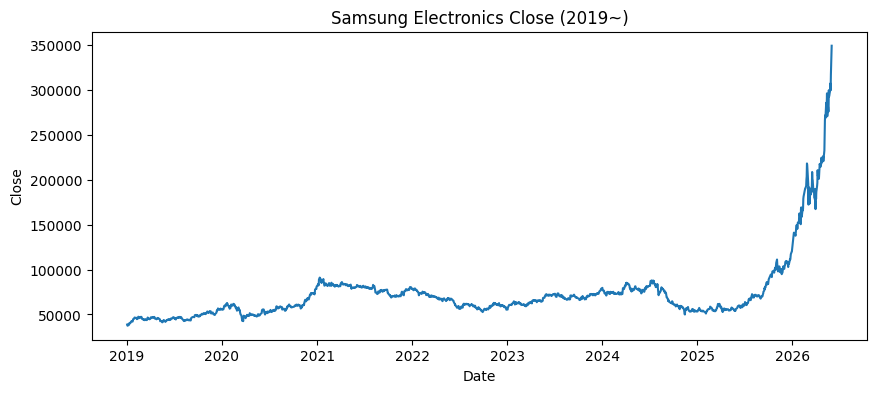

In [5]:
plt.figure(figsize=(10, 4))
sns.lineplot(x=df.index, y=df["Close"])
plt.title("Samsung Electronics Close (2019~)")
plt.xlabel("Date"); plt.ylabel("Close")
plt.show()

## 2. 월별 데이터 준비 (2023~2025)
월별 = 매월 종가 평균

In [6]:
import numpy as np
import warnings; warnings.filterwarnings('ignore')

m = df.loc['2023':'2025', 'Close'].resample('ME').mean()
m

Date
2023-01-31     60540.000000
2023-02-28     62320.000000
2023-03-31     61145.454545
2023-04-30     64855.000000
2023-05-31     66900.000000
2023-06-30     71676.190476
2023-07-31     71347.619048
2023-08-31     67686.363636
2023-09-30     70168.421053
2023-10-31     67910.526316
2023-11-30     71409.090909
2023-12-31     73810.526316
2024-01-31     74454.545455
2024-02-29     73684.210526
2024-03-31     75760.000000
2024-04-30     80595.238095
2024-05-31     77780.000000
2024-06-30     78831.578947
2024-07-31     84382.608696
2024-08-31     76500.000000
2024-09-30     66033.333333
2024-10-31     59295.000000
2024-11-30     55776.190476
2024-12-31     54035.000000
2025-01-31     54361.111111
2025-02-28     55665.000000
2025-03-31     57260.000000
2025-04-30     55686.363636
2025-05-31     55652.631579
2025-06-30     59200.000000
2025-07-31     65086.956522
2025-08-31     70470.000000
2025-09-30     77022.727273
2025-10-31     97111.111111
2025-11-30    100700.000000
2025-12-31    1

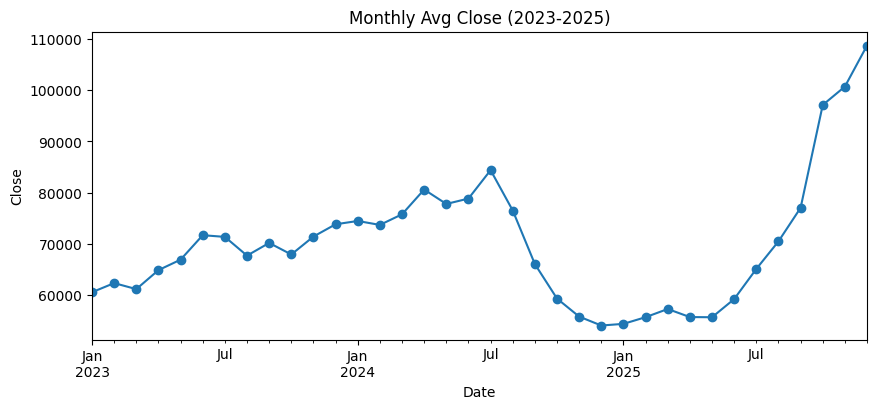

In [7]:
plt.figure(figsize=(10,4))
m.plot(marker='o')
plt.title("Monthly Avg Close (2023-2025)"); plt.ylabel("Close"); plt.show()

## 3. train / test 분리
train: 2023~2024 / test: 2025

In [8]:
train = m.loc['2023':'2024']
test  = m.loc['2025']
len(train), len(test)

(24, 12)

## 4. 세 가지 예측 모형

### 4.1 과거 평균 모형

In [9]:
pred_mean = pd.Series(train.mean(), index=test.index)

### 4.2 마지막 값 모형

In [10]:
pred_last = pd.Series(train.iloc[-1], index=test.index)

### 4.3 ARIMA 모형

#### 4.3.1 정상성 검정 (ADF) — p<0.05 면 정상

In [11]:
from statsmodels.tsa.stattools import adfuller

def adf(x, name):
    p = adfuller(x.dropna())[1]
    print(f"{name:8s}  p={p:.4f}  -> {'정상' if p<0.05 else '비정상'}")

adf(train,         'level')
adf(train.diff(),  'diff(1)')

level     p=0.3825  -> 비정상
diff(1)   p=0.0241  -> 정상


원계열 비정상 → 1차 차분 → **d = 1**

#### 4.3.2 optimize_ARIMA — (p,q) 그리드, AIC 최소

In [12]:
from statsmodels.tsa.arima.model import ARIMA
from itertools import product

def optimize_ARIMA(series, ps, qs, d):
    rows = []
    for p, q in product(ps, qs):
        try:
            aic = ARIMA(series, order=(p,d,q)).fit().aic
            rows.append((p, q, aic))
        except Exception:
            continue
    return pd.DataFrame(rows, columns=['p','q','AIC']).sort_values('AIC').reset_index(drop=True)

res = optimize_ARIMA(train, range(0,4), range(0,4), d=1)
res

/usr/local/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,p,q,AIC
0,0,0,450.093487
1,0,1,451.135433
2,1,0,451.190461
3,1,1,452.566256
4,2,0,453.105796
5,0,2,453.151053
6,3,0,453.821463
7,0,3,454.263145
8,2,1,454.544077
9,2,3,454.862062


In [13]:
p, q = int(res.iloc[0]['p']), int(res.iloc[0]['q'])
model = ARIMA(train, order=(p,1,q)).fit()
print(f"선택 모형: ARIMA({p},1,{q})")
model.summary()

선택 모형: ARIMA(0,1,0)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                   24
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -224.047
Date:                Mon, 01 Jun 2026   AIC                            450.093
Time:                        07:21:50   BIC                            451.229
Sample:                    01-31-2023   HQIC                           450.379
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1.638e+07    4.5e+06      3.644      0.000    7.57e+06    2.52e+07
===================================================================================
Ljung-Box (L1) (Q):                   3.05   Jarque-Bera (JB):                 2.21
Prob(Q):                              0.08   Prob(JB):                         0.33
Heteroskedasticity (H):               4.19   Skew:                            -0.76
Prob(H) (two-sided):                  0.06   Kurtosis:                         2.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### 4.3.3 잔차 검정

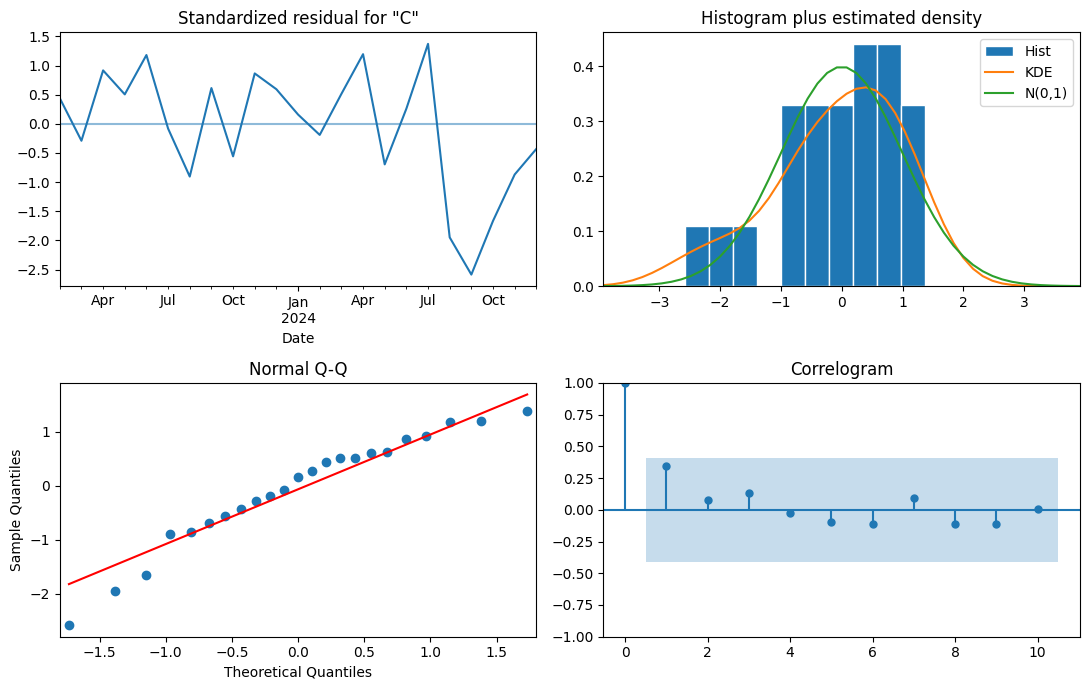

In [14]:
# 정성: 4-plot
model.plot_diagnostics(figsize=(11,7))
plt.tight_layout(); plt.show()

In [15]:
# 정량: Ljung-Box (p>0.05 → 잔차 백색잡음)
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(model.resid, lags=[5, 10], return_df=True)

,lb_stat,lb_pvalue
5,0.310991,0.997431
10,0.698259,0.999968


## 5. 모형 유효성 평가

### 5.1 ARIMA 12개월 예측 + Seasonal Naive baseline

In [16]:
pred_arima = model.forecast(steps=len(test))
pred_arima.index = test.index

# seasonal naive: 1년 전 같은 달
pred_snaive = pd.Series(train.iloc[-12:].values, index=test.index)

### 5.2 실제 vs 예측 시각화

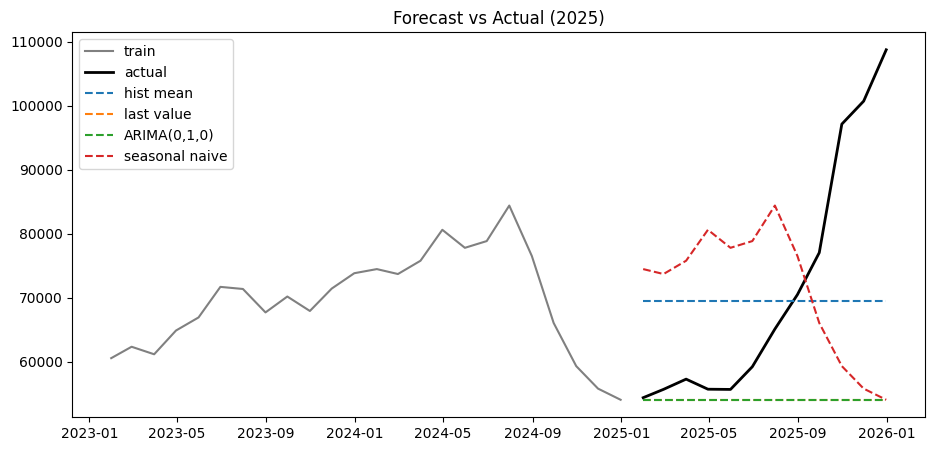

In [17]:
plt.figure(figsize=(11,5))
plt.plot(train.index, train, label='train', color='gray')
plt.plot(test.index,  test,  label='actual', color='black', lw=2)
plt.plot(test.index, pred_mean,   '--', label='hist mean')
plt.plot(test.index, pred_last,   '--', label='last value')
plt.plot(test.index, pred_arima,  '--', label=f'ARIMA({p},1,{q})')
plt.plot(test.index, pred_snaive, '--', label='seasonal naive')
plt.legend(); plt.title("Forecast vs Actual (2025)"); plt.show()

### 5.3 MAPE 비교

In [18]:
def mape(actual, pred):
    return (np.abs((actual - pred) / actual)).mean() * 100

pd.DataFrame({
    'model':   ['hist mean', 'last value', f'ARIMA({p},1,{q})', 'seasonal naive'],
    'MAPE(%)': [mape(test, pred_mean), mape(test, pred_last),
                mape(test, pred_arima), mape(test, pred_snaive)]
}).sort_values('MAPE(%)').reset_index(drop=True)

,model,MAPE(%)
0,last value,19.575302
1,"ARIMA(0,1,0)",19.575302
2,hist mean,21.190056
3,seasonal naive,33.801513


## 6. 결과 정리

- 2023~2025년 월평균 종가 36개월 중 train 24개월(23~24), test 12개월(25)
- ADF 검정에서 원계열은 비정상(p=0.38), 1차 차분 후 정상(p=0.02) → d=1 채택
- AIC 기준 최적 모형은 ARIMA(0,1,0), AIC 450.09
- 잔차는 Ljung-Box(lag5 p=0.997, lag10 p=0.9999)와 Jarque-Bera(p=0.33) 모두 통과해 백색잡음 가정에 부합
- 예측 성능(MAPE): last value 19.58%, ARIMA 19.58%, hist mean 21.19%, seasonal naive 33.80%

## 7. 결과 해석 및 원인 분석

- ARIMA가 단순 모형과 동일한 MAPE(19.58%)인 이유: 선택된 ARIMA(0,1,0)는 사실상 랜덤워크라 예측치가 train 마지막값으로 평탄하게 나옴 → last value와 결과 일치
- 이는 주가가 랜덤워크에 가깝다는 효율적 시장 가설과 맞아떨어지는 결과 (모형의 결함 아님)
- 가장 큰 오차 원인은 2025년 후반 급등: 학습기간 최고가 8.4만원 vs 테스트기간 최고 10.9만원 — 학습 분포 밖이라 시계열 모형으로 외삽 불가
- 급등 배경은 반도체 슈퍼사이클·AI 수요 등 외부 요인으로 추정되며, 과거 가격만으로는 학습 불가능한 정보
- 학습 표본 부족: 월별 24개월은 ARIMA 안정 추정에 부족(통상 50+ 권장), 표본 적을수록 단순 모형으로 수렴하는 경향
- Seasonal naive 최악(33.80%): 2024년 8~12월 하락 패턴(7.6만→5.4만)을 2025년에 그대로 적용했으나 실제는 후반 급등 → 1년 주기 계절성 가정이 주식에 부적합
- 로그 변환 미적용: 주가는 로그 정규분포에 가까워 보통 log 변환 후 ARIMA 적합이 일반적이나 본 분석은 원계열 직접 적용
- 결론적으로 오차의 본질은 모형 자체보다 학습기간 밖 외부 충격 및 데이터의 본질적 예측 불가능성에 가까움
- 개선 방향: 외생변수 포함(ARIMAX), 로그 변환, 학습기간 확장(2019~)